In [1]:
# Step 1: Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from catboost import CatBoostRegressor, Pool
import xgboost as xgb
import numpy as np

In [2]:
# Step 2:Importing Data
train = pd.read_csv("/kaggle/input/competitions/home-data-for-ml-course/train.csv")
test = pd.read_csv("/kaggle/input/competitions/home-data-for-ml-course/test.csv")

In [3]:
# Step 3: Data Preprocessing -> Categorizing data based on data types

# Categorical columns
object_cols = train.select_dtypes(include=['object', 'string']).columns.tolist()
print("Categorical variables:", len(object_cols))

# Integer columns
num_cols = train.select_dtypes(include=['int64', 'int32']).columns.tolist()
print("Integer variables:", len(num_cols))

# Float columns
fl_cols = train.select_dtypes(include=['float64', 'float32']).columns.tolist()
print("Float variables:", len(fl_cols))

Categorical variables: 43
Integer variables: 35
Float variables: 3


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


<Axes: >

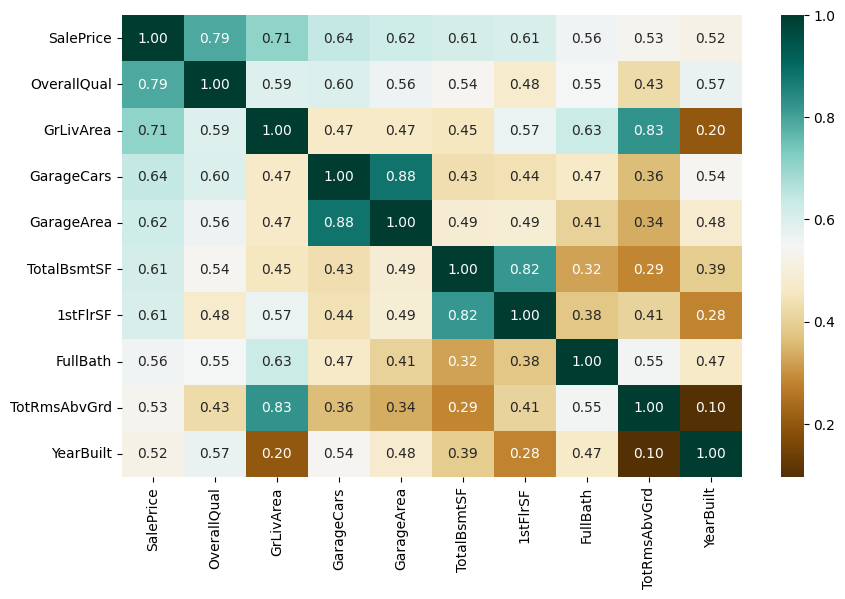

In [4]:
# Step 4: Exploring Data -> lets uncover patterns, detect anomalies, and understand the structire
numerical_train = train.select_dtypes(include=['number'])
corr_matrix = numerical_train.corr()
# Keep only correlations with SalePrice
top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(10)
print(top_corr)

plt.figure(figsize=(10,6))
sns.heatmap(numerical_train[top_corr.index].corr(), annot=True, cmap='BrBG', fmt='.2f')

SalePrice skew: 1.8828757597682129


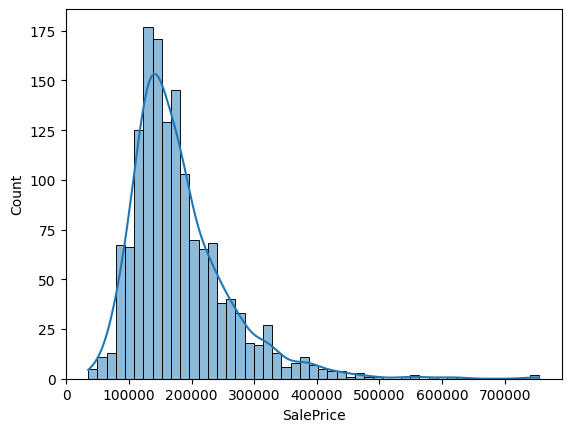

In [5]:
# Step 5: Data Cleaning
print("SalePrice skew:", train["SalePrice"].skew())
sns.histplot(train["SalePrice"], kde=True)
plt.show()

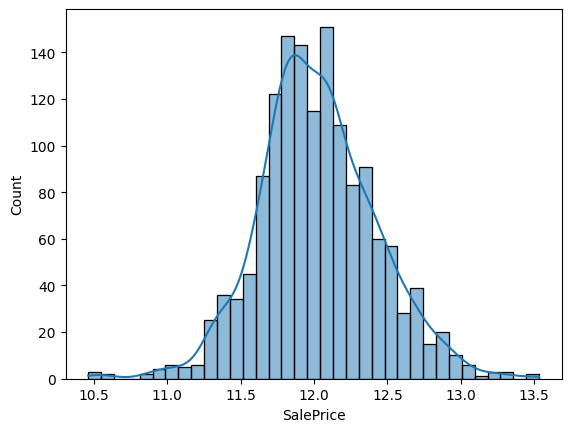

The new skew is  0.12134661989685333


In [6]:
# Step 6: Data Cleaning
#6.1 Its too skewed so i can now use log transformation to reduce the skewness
train["SalePrice"] = np.log1p(train["SalePrice"])
sns.histplot(train["SalePrice"], kde=True)
plt.show()
print("The new skew is ", train["SalePrice"].skew())

In [7]:
# 6.2 Other data could also be skewed
numeric_feats = train.select_dtypes(include=['int64','float64']).columns
skewed_feats = train[numeric_feats].apply(lambda x: x.skew()).sort_values(ascending=False)
skewed_feats = skewed_feats[abs(skewed_feats) > 0.75]  # threshold
print(skewed_feats)

for feat in skewed_feats.index:
    if feat != 'SalePrice':
        train[feat] = np.log1p(train[feat])

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
dtype: float64


Features to transform: ['PoolArea', '3SsnPorch', 'LowQualFinSF', 'MiscVal', 'BsmtHalfBath', 'KitchenAbvGr', 'ScreenPorch', 'BsmtFinSF2', 'EnclosedPorch', 'BsmtUnfSF', 'TotalBsmtSF']


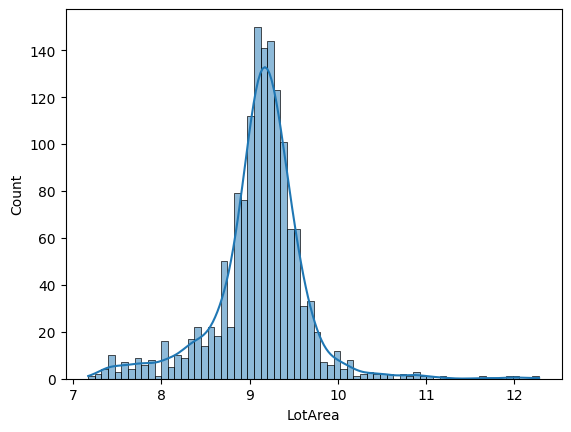

In [8]:
# Select numeric features again
numeric_feats = train.select_dtypes(include=['int64','float64']).columns

# Calculate skew
skewed_feats = train[numeric_feats].apply(lambda x: x.skew()).sort_values(ascending=False)
skewed_feats = skewed_feats[abs(skewed_feats) > 0.75]
print("Features to transform:", skewed_feats.index.tolist())

# Apply log1p
for feat in skewed_feats.index:
    if feat != 'SalePrice':
        train[feat] = np.log1p(train[feat])

# Check one example
sns.histplot(train['LotArea'], kde=True)
plt.show()

In [9]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [10]:
# 6.3: Outlier Removal
# Fill categorical "no feature"(Na) columns with 'None'
none_cols = ['PoolQC','MiscFeature','Alley','Fence',
             'FireplaceQu','BsmtQual','BsmtCond','BsmtExposure',
             'BsmtFinType1','BsmtFinType2','GarageType','GarageFinish',
             'GarageQual','GarageCond','MasVnrType']
for col in none_cols:
    train[col] = train[col].fillna('None')

# Fill numeric "no feature" columns with 0
zero_cols = ['MasVnrArea','GarageYrBlt']
for col in zero_cols:
    train[col] = train[col].fillna(0)

# Fill LotFrontage with median of neighborhood
train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Fill Electrical with mode
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

In [11]:
# Step 7: Encoding Feuatures
# 7.1 Ordinal Feutures -> map to numbers
# Quality/Condition mapping
qual_map = {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, 'None':0}

ordinal_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond',
                'HeatingQC','KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']

for col in ordinal_cols:
    train[col] = train[col].map(qual_map)

In [12]:
# 7.2:Remaining Category -> One hot Encode
# Select remaining object/string columns
cat_cols = train.select_dtypes(include=['object', 'string']).columns

# Apply one-hot encoding
train_encoded = pd.get_dummies(train, columns=cat_cols, drop_first=True)
print("Shape before encoding", train.shape)
print("Shape after encoding:", train_encoded.shape)

Shape before encoding (1460, 81)
Shape after encoding: (1460, 231)


In [13]:
# Step 9: Train/Test Split & Scaling
# 9.1: Separate feutures and target
X = train_encoded.drop('SalePrice', axis=1)
y = train_encoded['SalePrice']

In [14]:
# 9.2: train/test split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
# Scale numeric feutures
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

In [16]:
# STep 10: Model Training and Accuracy
# 10.1: Ridge
# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_valid_scaled)
rmse_ridge = np.sqrt(mean_squared_error(y_valid, y_pred_ridge))
print("Ridge RMSE:", rmse_ridge)

Ridge RMSE: 0.12742196215223414


In [17]:
# 10.2 Lasso
lasso = Lasso(alpha=0.001)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_valid_scaled)
rmse_lasso = np.sqrt(mean_squared_error(y_valid, y_pred_lasso))
print("Lasso RMSE:", rmse_lasso)

Lasso RMSE: 0.13296676131508736


In [18]:
# 10.3 ElasticNet
enet = ElasticNet(alpha=0.001, l1_ratio=0.5)
enet.fit(X_train_scaled, y_train)
y_pred_enet = enet.predict(X_valid_scaled)
rmse_enet = np.sqrt(mean_squared_error(y_valid, y_pred_enet))
print("ElasticNet RMSE:", rmse_enet)

ElasticNet RMSE: 0.1313907576006561


In [19]:
# Step 11: Gradient Boosting
# Gradient Boosting
gbr = GradientBoostingRegressor(n_estimators=1000, learning_rate=0.05, max_depth=4, random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_valid)
rmse_gbr = np.sqrt(mean_squared_error(y_valid, y_pred_gbr))
print("Gradient Boosting RMSE:", rmse_gbr)


Gradient Boosting RMSE: 0.13879455336104843


In [20]:
# XGBoost
xgbr = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42)
xgbr.fit(X_train, y_train)
y_pred_xgb = xgbr.predict(X_valid)
rmse_xgb = np.sqrt(mean_squared_error(y_valid, y_pred_xgb))
print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 0.1356844760366371


In [21]:
# XGBoost should be better at this, lets do some hyperparameter 
# tuning to see if it will perform better
xgbr = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [500, 800, 1000],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2, 3],
    'min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=xgbr,
    param_distributions=param_grid,
    n_iter=30, # faster than full grd but its not that bad coverage at all
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best RMSE:", -random_search.best_score_)
print("Best params:", random_search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best RMSE: 0.12448796416044784
Best params: {'subsample': 0.6, 'reg_lambda': 3, 'reg_alpha': 0.01, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


In [22]:
# We already have rmse, just trying to compare MAE and MSE
rmse = np.sqrt(mean_squared_error(y_valid, y_pred_xgb))
mae = mean_absolute_error(y_valid, y_pred_xgb)

print(f"XGBoost RMSE (log SalePrice): {rmse:.5f}")
print(f"XGBoost MAE (log SalePrice): {mae:.5f}")

XGBoost RMSE (log SalePrice): 0.13568
XGBoost MAE (log SalePrice): 0.08779


In [23]:
# Testing magnitude
rmse_real = np.sqrt(mean_squared_error(np.expm1(y_valid), np.expm1(y_pred_xgb)))
mae_real = mean_absolute_error(np.expm1(y_valid), np.expm1(y_pred_xgb))

print(f"XGBoost RMSE (actual SalePrice $): {rmse_real:.2f}")
print(f"XGBoost MAE (actual SalePrice $): {mae_real:.2f}")

XGBoost RMSE (actual SalePrice $): 25930.72
XGBoost MAE (actual SalePrice $): 15378.51


In [24]:
# Step 13: CatBoost Regression (using original train data)
# Separate features and target
X_cat = train.drop('SalePrice', axis=1)
y_cat = train['SalePrice']

# Identify categorical columns
cat_features = X_cat.select_dtypes(include=['object', 'string']).columns.tolist()
print("Categorical features:", len(cat_features))

# Train/test split
X_train_cat, X_valid_cat, y_train_cat, y_valid_cat = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42
)

# Create CatBoost Pool objects (optional but useful)
train_pool = Pool(X_train_cat, y_train_cat, cat_features=cat_features)
valid_pool = Pool(X_valid_cat, y_valid_cat, cat_features=cat_features)

# Initialize CatBoost regressor
cat_model = CatBoostRegressor(
    iterations=1000,          # number of trees
    learning_rate=0.05,
    depth=6,
    eval_metric='RMSE',
    random_seed=42,
    verbose=100,             # prints every 100 trees
    early_stopping_rounds=50 # stop if no improvement
)

# Fit the model
cat_model.fit(train_pool, eval_set=valid_pool)

# Predict
y_pred_cat = cat_model.predict(X_valid_cat)

# Evaluate
rmse_cat = np.sqrt(mean_squared_error(y_valid_cat, y_pred_cat))
mae_cat = mean_absolute_error(y_valid_cat, y_pred_cat)
print(f"CatBoost RMSE (log SalePrice): {rmse_cat:.5f}")
print(f"CatBoost MAE (log SalePrice): {mae_cat:.5f}")

# Optional: evaluate on real SalePrice scale
rmse_cat_real = np.sqrt(mean_squared_error(np.expm1(y_valid_cat), np.expm1(y_pred_cat)))
mae_cat_real = mean_absolute_error(np.expm1(y_valid_cat), np.expm1(y_pred_cat))
print(f"CatBoost RMSE (actual SalePrice $): {rmse_cat_real:.2f}")
print(f"CatBoost MAE (actual SalePrice $): {mae_cat_real:.2f}")

Categorical features: 33
0:	learn: 0.3781838	test: 0.4203022	best: 0.4203022 (0)	total: 67ms	remaining: 1m 6s
100:	learn: 0.1112965	test: 0.1459356	best: 0.1459356 (100)	total: 1.06s	remaining: 9.48s
200:	learn: 0.0896711	test: 0.1348894	best: 0.1348894 (200)	total: 2.05s	remaining: 8.15s
300:	learn: 0.0778102	test: 0.1312948	best: 0.1312948 (300)	total: 3.12s	remaining: 7.24s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1308263499
bestIteration = 332

Shrink model to first 333 iterations.
CatBoost RMSE (log SalePrice): 0.13083
CatBoost MAE (log SalePrice): 0.08855
CatBoost RMSE (actual SalePrice $): 27061.83
CatBoost MAE (actual SalePrice $): 16077.38


In [25]:
# Random Forest Regression Model
# Use the preprocessed train_encoded (one-hot) data
X_rf = train_encoded.drop('SalePrice', axis=1)
y_rf = train_encoded['SalePrice']

# Train/test split
X_train_rf, X_valid_rf, y_train_rf, y_valid_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

# Initialize Random Forest
rf_model = RandomForestRegressor(
    n_estimators=500,      # number of trees
    max_depth=None,        # let trees grow fully
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

# Fit
rf_model.fit(X_train_rf, y_train_rf)

# Predict
y_pred_rf = rf_model.predict(X_valid_rf)

# Evaluate
rmse_rf = np.sqrt(mean_squared_error(y_valid_rf, y_pred_rf))
mae_rf = mean_absolute_error(y_valid_rf, y_pred_rf)

print(f"Random Forest RMSE (log SalePrice): {rmse_rf:.5f}")
print(f"Random Forest MAE (log SalePrice): {mae_rf:.5f}")

# Optional: actual $ scale
rmse_rf_real = np.sqrt(mean_squared_error(np.expm1(y_valid_rf), np.expm1(y_pred_rf)))
mae_rf_real = mean_absolute_error(np.expm1(y_valid_rf), np.expm1(y_pred_rf))

print(f"Random Forest RMSE (actual SalePrice $): {rmse_rf_real:.2f}")
print(f"Random Forest MAE (actual SalePrice $): {mae_rf_real:.2f}")

Random Forest RMSE (log SalePrice): 0.14812
Random Forest MAE (log SalePrice): 0.09843
Random Forest RMSE (actual SalePrice $): 30208.27
Random Forest MAE (actual SalePrice $): 17520.60


In [26]:
# Observations after comparing the different models
# Table Comparison
# Create a summary table
model_comparison = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "ElasticNet", "Gradient Boosting", "XGBoost (tuned)", "CatBoost", "Random Forest"],
    "RMSE (log SalePrice)": [0.12742, 0.13297, 0.13139, 0.13879, 0.13568, 0.13083, 0.14812],
    "RMSE (actual $)": [None, None, None, None, 25930.72, 27061.83, 30208.27],
    "MAE (log SalePrice)": [None, None, None, None, 0.08779, 0.08855, 0.09843],
    "MAE (actual $)": [None, None, None, None, 15378.51, 16077.38, 17520.60]
})

# Rank models by RMSE (log SalePrice)
model_comparison['Rank (RMSE)'] = model_comparison['RMSE (log SalePrice)'].rank(method='min')
model_comparison = model_comparison.sort_values('Rank (RMSE)').reset_index(drop=True)

print(model_comparison)

               Model  RMSE (log SalePrice)  RMSE (actual $)  \
0              Ridge               0.12742              NaN   
1           CatBoost               0.13083         27061.83   
2         ElasticNet               0.13139              NaN   
3              Lasso               0.13297              NaN   
4    XGBoost (tuned)               0.13568         25930.72   
5  Gradient Boosting               0.13879              NaN   
6      Random Forest               0.14812         30208.27   

   MAE (log SalePrice)  MAE (actual $)  Rank (RMSE)  
0                  NaN             NaN          1.0  
1              0.08855        16077.38          2.0  
2                  NaN             NaN          3.0  
3                  NaN             NaN          4.0  
4              0.08779        15378.51          5.0  
5                  NaN             NaN          6.0  
6              0.09843        17520.60          7.0  


In [27]:
# I chose RMSE (Root Mean Squared Error) over MAE (Mean Absolute Error) as the primary metric because RMSE penalizes larger errors more heavily. In the context of predicting house prices, a $100k error on an expensive home is far more significant than a $1k error on a cheaper one. RMSE ensures that our model pays extra attention to these high-cost mistakes, which aligns better with the real-world impact of inaccurate predictions. MAE was also computed to provide a sense of the “average error,” but RMSE is more sensitive to large deviations, making it the preferred metric for evaluating our models.

In [28]:
# Ordinal mapping used in training
qual_map = {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, 'None':0}

ordinal_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond',
                'HeatingQC','KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']
test_X = test.copy()
# Apply the mapping to the test set
for col in ordinal_cols:
    if col in test_X.columns:
        # Fill missing with 'None' first, then map
        test_X[col] = test_X[col].fillna('None')
        test_X[col] = test_X[col].map(qual_map)
        
# Identify categorical columns (remaining object/string columns)
cat_cols_test = test_X.select_dtypes(include=['object', 'string']).columns.tolist()

# Fill any remaining NaNs in categorical features
for col in cat_cols_test:
    test_X[col] = test_X[col].fillna('None')

# Create Pool
test_pool = Pool(test_X, cat_features=cat_cols_test)

# Predict
preds_log = cat_model.predict(test_pool)

# Reverse log1p
preds_final = np.expm1(preds_log)

# Create submission
submission = pd.DataFrame({
    "Id": test_X["Id"],
    "SalePrice": preds_final
})

submission.to_csv("final_catboost_submission.csv", index=False)
print("Submission file created: final_catboost_submission.csv")

Submission file created: final_catboost_submission.csv


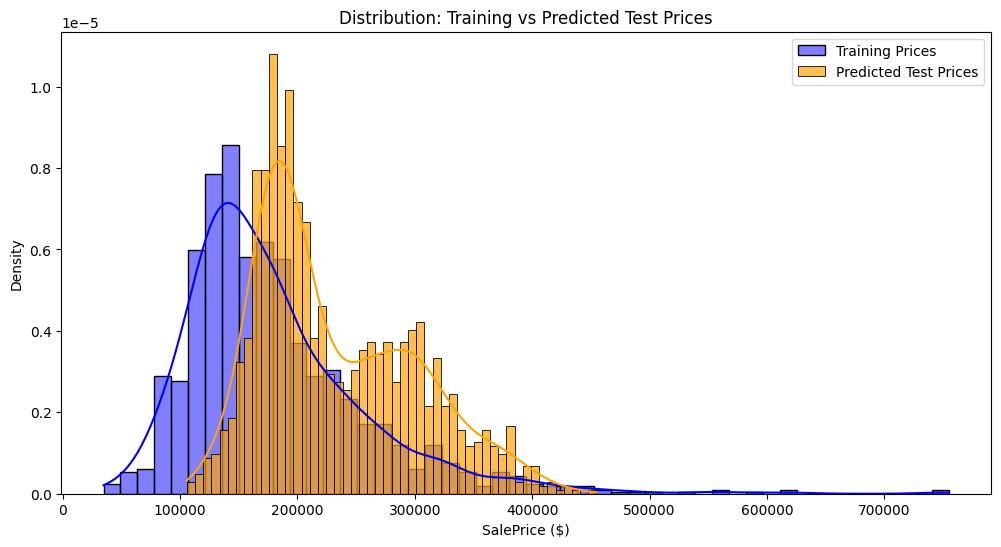

In [29]:
# Results Test to see if am way off
# Training SalePrice (actual)
train_prices = np.expm1(train["SalePrice"])  # reverse log1p

# Test SalePrice (predicted)
test_prices = preds_final

plt.figure(figsize=(12,6))
sns.histplot(train_prices, color='blue', label='Training Prices', kde=True, stat="density", bins=50)
sns.histplot(test_prices, color='orange', label='Predicted Test Prices', kde=True, stat="density", bins=50, alpha=0.7)
plt.xlabel("SalePrice ($)")
plt.ylabel("Density")
plt.title("Distribution: Training vs Predicted Test Prices")
plt.legend()
plt.show()